In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# %cd /content/drive/MyDrive/CS464/
# !mkdir -p FMA
# %cd FMA
# !git clone https://github.com/mdeff/fma.git
# !curl -O https://os.unil.cloud.switch.ch/fma/fma_small.zip
# !
# !echo "ade154f733639d52e35e32f5593efe5be76c6d70  fma_small.zip"    | sha1sum -c -
# !
# !unzip fma_small.zip
# !
# !cd ..

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



=== Processing Feature: MFCC ===
Error with 099134.mp3: 
Error with 108925.mp3: 
Error with 133297.mp3: 


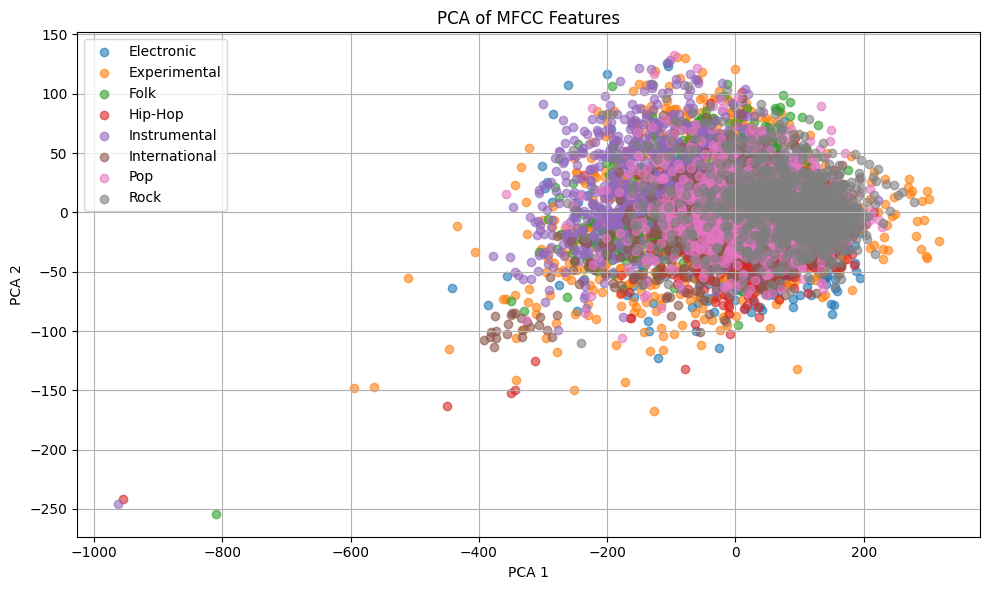


🧪 Feature Mode: MFCC

🔹 Random Forest
Test Accuracy: 0.4170
Test F1 Score: 0.4047
CV Accuracy (mean): 0.3715
CV F1 Score (mean): 0.3606


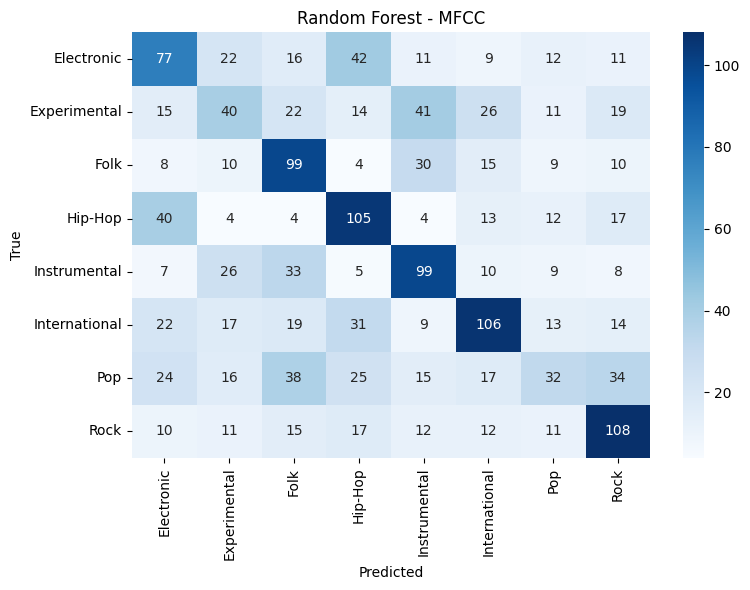


🔹 SVM
Test Accuracy: 0.3820
Test F1 Score: 0.3627
CV Accuracy (mean): 0.3582
CV F1 Score (mean): 0.3372


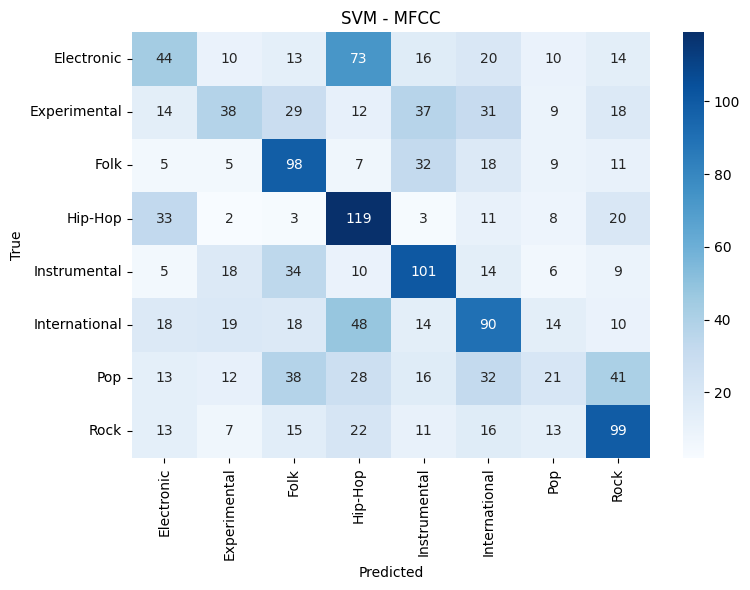


🔹 MLP
Test Accuracy: 0.3826
Test F1 Score: 0.3803
CV Accuracy (mean): 0.3294
CV F1 Score (mean): 0.3243


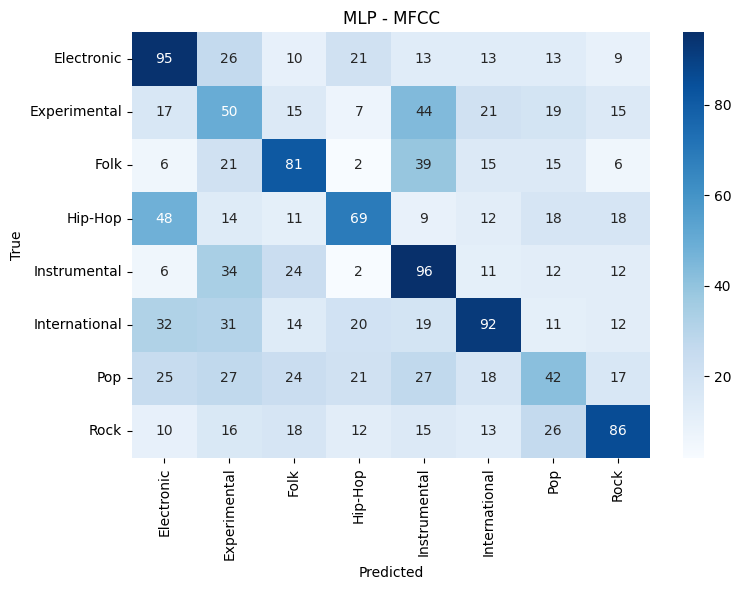


🔹 KNN
Test Accuracy: 0.3538
Test F1 Score: 0.3500
CV Accuracy (mean): 0.3089
CV F1 Score (mean): 0.3056


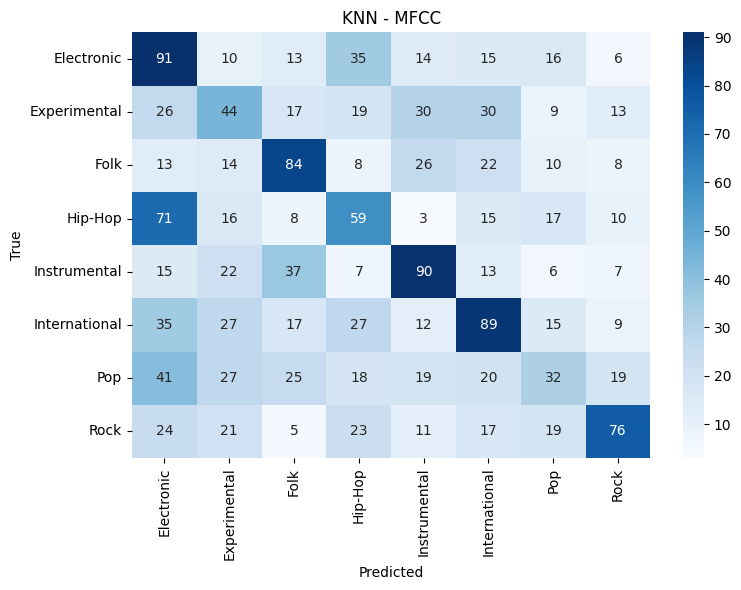


=== Processing Feature: CHROMA ===
Error with 099134.mp3: 
Error with 108925.mp3: 
Error with 133297.mp3: 


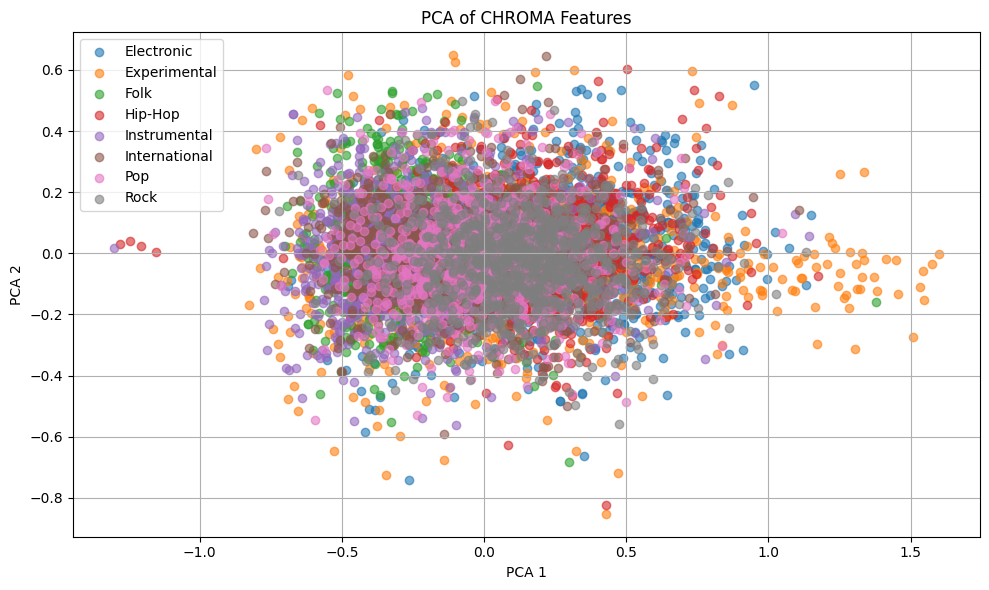


🧪 Feature Mode: CHROMA

🔹 Random Forest
Test Accuracy: 0.2974
Test F1 Score: 0.2868
CV Accuracy (mean): 0.2800
CV F1 Score (mean): 0.2682


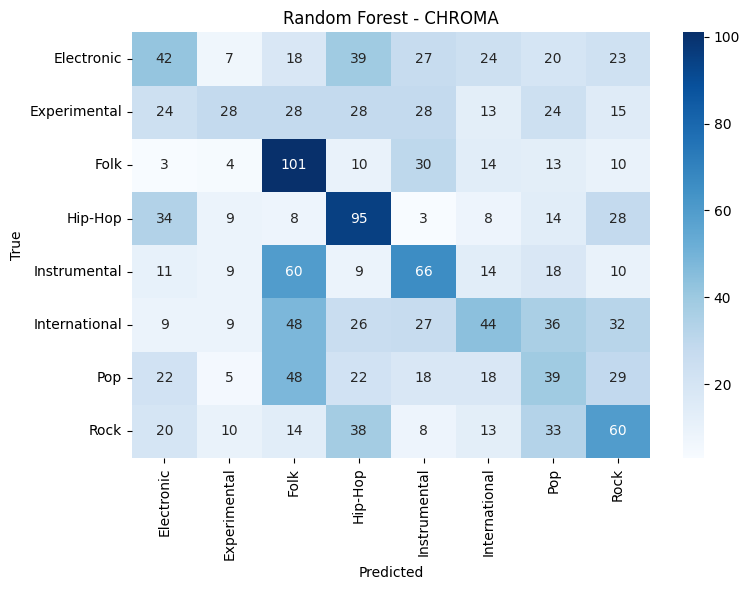


🔹 SVM
Test Accuracy: 0.3200
Test F1 Score: 0.3061
CV Accuracy (mean): 0.3004
CV F1 Score (mean): 0.2858


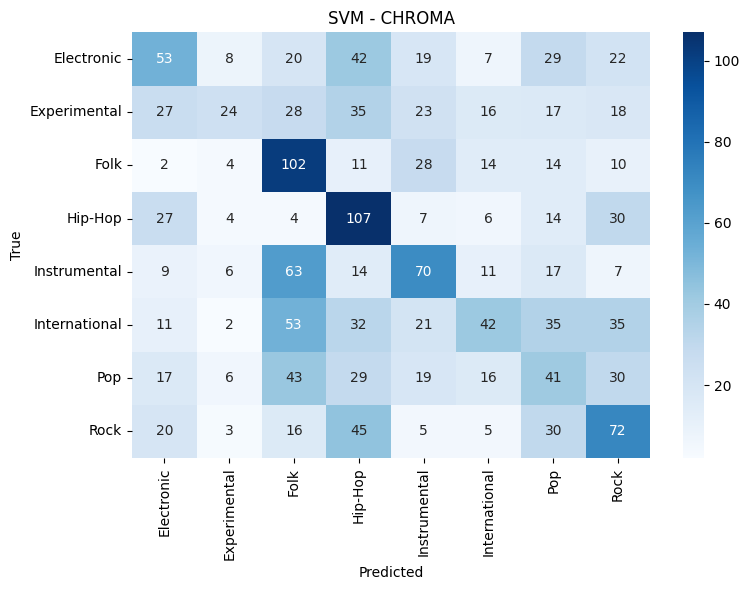


🔹 MLP
Test Accuracy: 0.3100
Test F1 Score: 0.3058
CV Accuracy (mean): 0.2969
CV F1 Score (mean): 0.2879


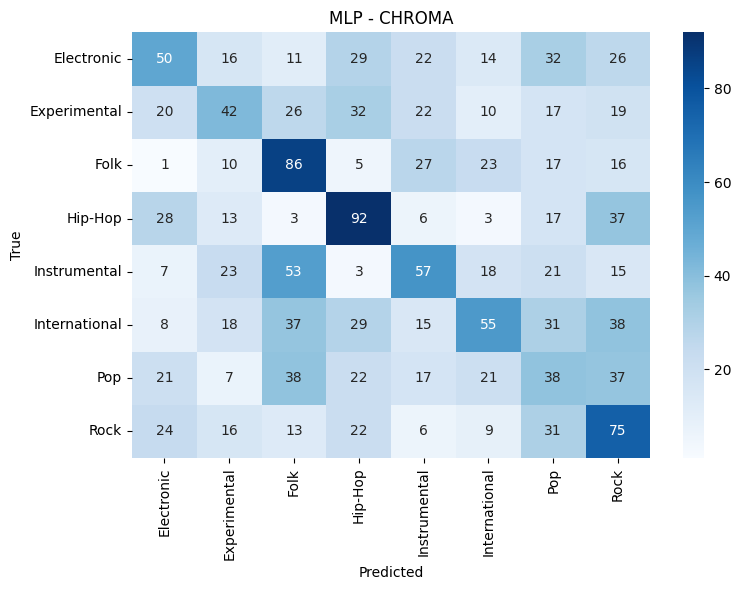


🔹 KNN
Test Accuracy: 0.2668
Test F1 Score: 0.2604
CV Accuracy (mean): 0.2437
CV F1 Score (mean): 0.2336


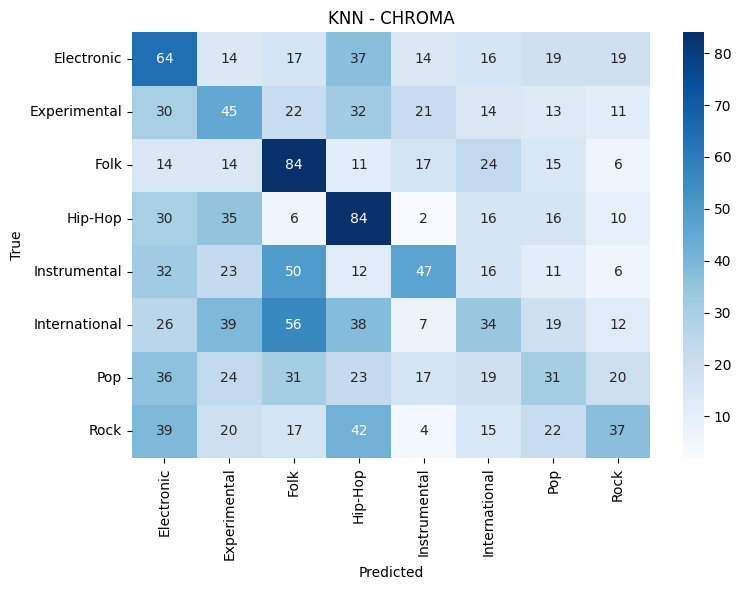


=== Processing Feature: MFCC+CHROMA ===
Error with 099134.mp3: 
Error with 108925.mp3: 
Error with 133297.mp3: 


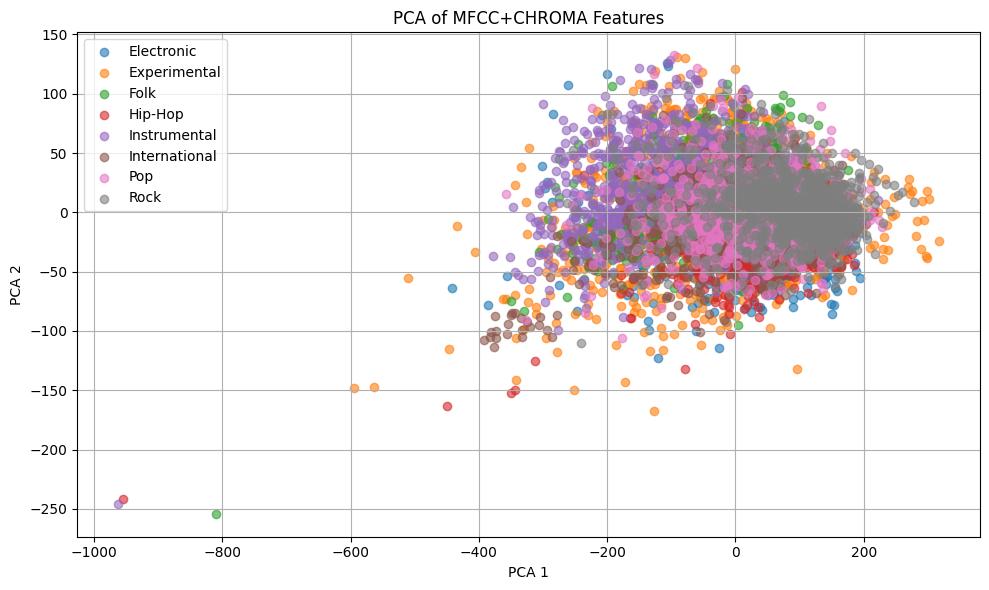


🧪 Feature Mode: MFCC+CHROMA

🔹 Random Forest
Test Accuracy: 0.4377
Test F1 Score: 0.4275
CV Accuracy (mean): 0.3975
CV F1 Score (mean): 0.3873


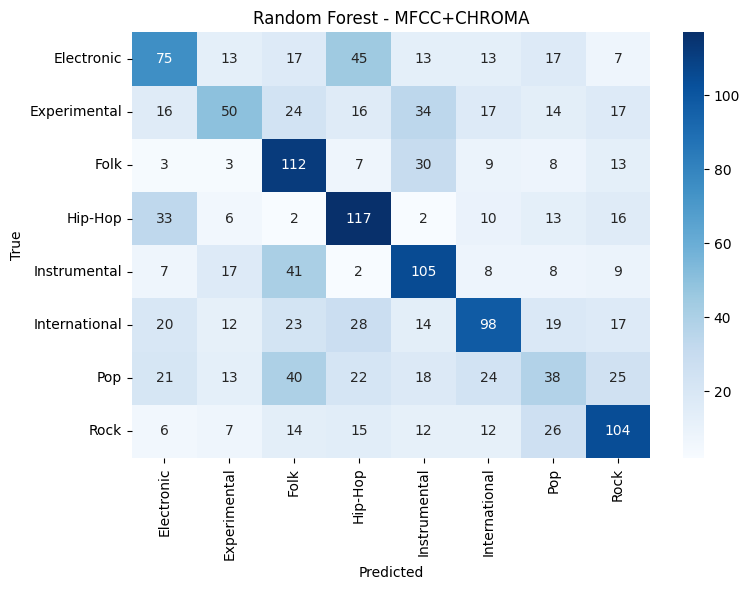


🔹 SVM
Test Accuracy: 0.3813
Test F1 Score: 0.3617
CV Accuracy (mean): 0.3581
CV F1 Score (mean): 0.3371


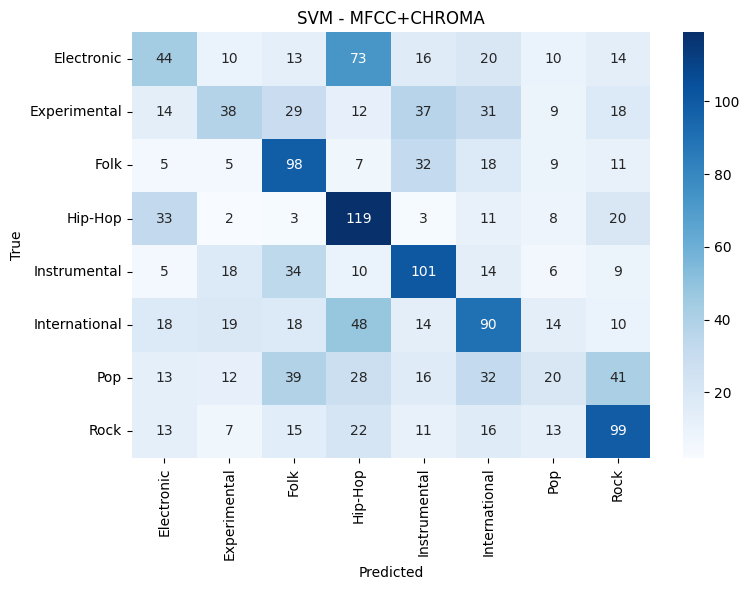


🔹 MLP
Test Accuracy: 0.4064
Test F1 Score: 0.4047
CV Accuracy (mean): 0.3395
CV F1 Score (mean): 0.3366


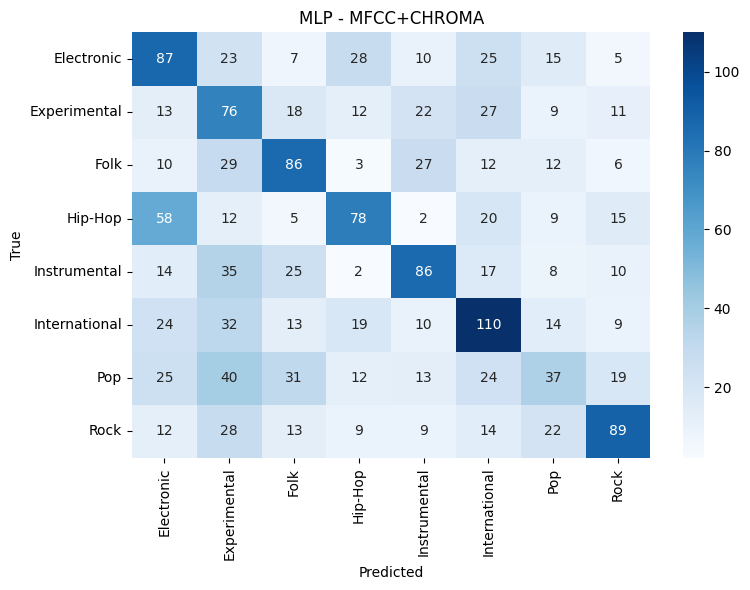


🔹 KNN
Test Accuracy: 0.3538
Test F1 Score: 0.3500
CV Accuracy (mean): 0.3093
CV F1 Score (mean): 0.3060


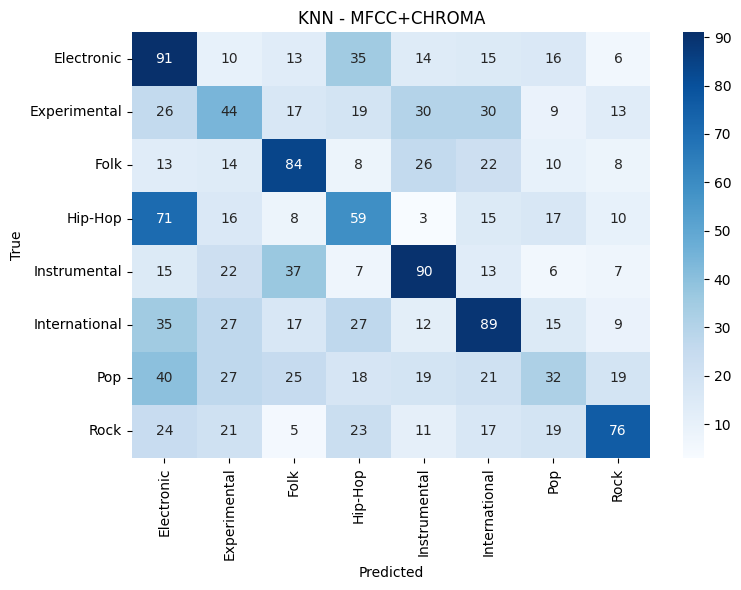

✅ Results saved to model_results.csv


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# === Load Metadata ===
TRACKS_CSV_PATH = "/content/drive/MyDrive/CS464/FMA/fma_metadata/tracks.csv"
tracks = pd.read_csv(TRACKS_CSV_PATH, index_col=0, header=[0, 1])
track_genre_map = tracks[('track', 'genre_top')]

# === Feature Extraction ===
def extract_features(audio, sr, mode="mfcc+chroma"):
    if mode == "mfcc":
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        return np.mean(mfccs, axis=1)
    elif mode == "chroma":
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        return np.mean(chroma, axis=1)
    elif mode == "mfcc+chroma":
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        combined = np.concatenate((mfccs, chroma), axis=0)
        return np.mean(combined, axis=1)
    else:
        raise ValueError("Invalid mode")

def preprocess_audio(file_path, sr=22050, duration=30, mode="mfcc+chroma"):
    samples = sr * duration
    audio, _ = librosa.load(file_path, sr=sr, mono=True, duration=duration)
    if len(audio) < samples:
        audio = np.pad(audio, (0, samples - len(audio)), mode='constant')
    else:
        audio = audio[:samples]
    return extract_features(audio, sr, mode=mode)

# === Dataset Extraction (Real Genres) ===
def extract_dataset_features(dataset_path, mode="mfcc+chroma"):
    features, labels = [], []
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith('.mp3'):
                try:
                    path = os.path.join(root, file)
                    track_id = int(os.path.splitext(file)[0])
                    if track_id not in track_genre_map:
                        continue
                    genre = track_genre_map[track_id]
                    if pd.isna(genre):
                        continue
                    feat = preprocess_audio(path, mode=mode)
                    features.append(feat)
                    labels.append(genre)
                except Exception as e:
                    print(f"Error with {file}: {e}")
    return np.array(features), np.array(labels)

# === PCA Visualization ===
def visualize_pca(X, y, title="PCA"):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(10, 6))
    for genre in np.unique(y):
        idx = y == genre
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=genre, alpha=0.6)
    plt.legend()
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Confusion Matrix Plot ===
def plot_confusion(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# === Model Training and Evaluation ===
def train_and_evaluate(X, y, mode_label="", results=[]):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"\n🧪 Feature Mode: {mode_label}")

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM": SVC(kernel='rbf', gamma='scale'),
        "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5)
    }

    for name, model in models.items():
        print(f"\n🔹 {name}")
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='macro')
        cv_acc = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
        cv_f1 = cross_val_score(model, X, y, cv=5, scoring='f1_macro').mean()

        print(f"Test Accuracy: {acc:.4f}")
        print(f"Test F1 Score: {f1:.4f}")
        print(f"CV Accuracy (mean): {cv_acc:.4f}")
        print(f"CV F1 Score (mean): {cv_f1:.4f}")

        results.append({
            "Feature": mode_label,
            "Model": name,
            "Test Accuracy": acc,
            "Test F1": f1,
            "CV Accuracy": cv_acc,
            "CV F1": cv_f1
        })

        plot_confusion(y_test, preds, classes=np.unique(y), title=f"{name} - {mode_label}")

# === Main Run ===
if __name__ == "__main__":
    DATASET_PATH = "/content/drive/MyDrive/CS464/FMA/fma_small"  # Adjust this
    all_results = []

    for mode in ["mfcc", "chroma", "mfcc+chroma"]:
        print(f"\n=== Processing Feature: {mode.upper()} ===")
        X, y = extract_dataset_features(DATASET_PATH, mode=mode)

        if len(X) == 0:
            print(f"⚠️ No features extracted for mode {mode.upper()} — skipping.")
            continue

        visualize_pca(X, y, title=f"PCA of {mode.upper()} Features")
        train_and_evaluate(X, y, mode_label=mode.upper(), results=all_results)

    # Save results to CSV
    df = pd.DataFrame(all_results)
    df.to_csv("model_results.csv", index=False)
    print("✅ Results saved to model_results.csv")
